# EDA 2 - Retrato da nova carga imobiliária

Esta EDA descreve a nova execução do pipeline sem alterar os dados e sem redefinir as regras de qualidade. O objetivo é produzir um retrato para investigação posterior.

A análise cobre: volume por camada, schema, cobertura das variáveis, distribuição por tipo e bairro, flags de suspeita, motivos das flags, preços, áreas e a composição dos splits temporais.

> Execute o pipeline Bronze -> Silver -> Gold antes deste notebook. Os caminhos abaixo partem da pasta `notebooks`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

base_dir = Path.cwd().resolve().parent
bronze_dir = base_dir / 'data' / 'bronze'
silver_dir = base_dir / 'data' / 'silver'
gold_dir = base_dir / 'data' / 'gold'
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [2]:
silver = pd.read_parquet(silver_dir / 'imoveis_limpos.parquet')
gold = pd.read_parquet(gold_dir / 'fact_imoveis_gold.parquet')
stats = pd.read_parquet(gold_dir / 'dim_bairros_estatisticas.parquet')
splits = {
    'train': pd.read_parquet(gold_dir / 'ml_train.parquet'),
    'valid': pd.read_parquet(gold_dir / 'ml_valid.parquet'),
    'test': pd.read_parquet(gold_dir / 'ml_test.parquet'),
}
print('Silver:', silver.shape)
print('Gold:', gold.shape)
print('Estatisticas:', stats.shape)
for name, frame in splits.items():
    print(f'ML {name}: {frame.shape}')

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

## 1. Volume e schema

Primeiro verificamos se as camadas preservam o mesmo volume e quais colunas foram criadas ou removidas em cada etapa.

In [ ]:
bronze_jsons = sorted(bronze_dir.glob('*.json'))
bronze_summary = []
for path in bronze_jsons:
    frame = pd.read_json(path)
    bronze_summary.append({'arquivo': path.name, 'registros': len(frame), 'colunas': len(frame.columns)})
pd.DataFrame(bronze_summary)

,arquivo,registros,colunas
0,scraping_20260919_205345.json,900,17


In [ ]:
schema_summary = pd.DataFrame({
    'silver': pd.Series(silver.dtypes.astype(str)),
    'gold': pd.Series(gold.dtypes.astype(str)),
})
schema_summary

,silver,gold
area_cat,NaN,str
area_m2,float64,float64
area_mad,NaN,float64
area_med,NaN,float64
bairro,str,str
bairro_area_cross,NaN,str
cidade,NaN,object
data_extracao,float64,float64
descricao,str,NaN
descricao_completa,str,str


In [ ]:
print('Colunas somente na Silver:', sorted(set(silver.columns) - set(gold.columns)))
print('Colunas somente na Gold:', sorted(set(gold.columns) - set(silver.columns)))
print('IDs Silver unicos:', silver['id_hex'].nunique())
print('IDs Gold unicos:', gold['id_imovel'].nunique())

Colunas somente na Silver: ['descricao', 'descricao_len', 'id_hex', 'ingestion_datetime', 'pipeline_version', 'source_file', 'titulo_len']
Colunas somente na Gold: ['area_cat', 'area_mad', 'area_med', 'bairro_area_cross', 'cidade', 'id_bairro_fk', 'id_imobiliaria_fk', 'id_imovel', 'imobiliaria_hash', 'preco_mad', 'preco_med', 'target_preco', 'uf']
IDs Silver unicos: 900
IDs Gold unicos: 900


## 2. Cobertura dos atributos

As colunas abaixo foram mantidas para descrever a qualidade da nova coleta. Nulos e valores imputados devem ser analisados separadamente.

In [ ]:
coverage = (
    silver.notna().mean()
    .sort_values()
    .rename('proporcao_preenchida')
)
coverage.to_frame().assign(percentual=lambda frame: frame['proporcao_preenchida'] * 100)

,proporcao_preenchida,percentual
area_m2,0.997778,99.777778
preco_por_m2,0.997778,99.777778
url,1.000000,100.000000
id_hex,1.000000,100.000000
descricao,1.000000,100.000000
descricao_completa,1.000000,100.000000
quartos,1.000000,100.000000
titulo,1.000000,100.000000
suites,1.000000,100.000000
vagas,1.000000,100.000000


In [ ]:
numeric_columns = [column for column in ['preco', 'area_m2', 'preco_por_m2', 'quartos', 'suites', 'vagas'] if column in silver.columns]
silver[numeric_columns].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
preco,900.0,20415.274444,59686.092281,140.0,600.0,3200.0,6225.0,16000.0,240079.18,1300000.0
area_m2,898.0,391.410913,1078.856146,1.0,21.97,48.0,110.0,352.5,4943.0,20000.0
preco_por_m2,898.0,110.572138,1086.126332,2.1,5.49,36.0275,56.39,80.9975,251.1208,32000.0
quartos,900.0,2.307778,1.038602,1.0,1.0,2.0,2.0,3.0,6.0,9.0
suites,900.0,1.36,0.905649,1.0,1.0,1.0,1.0,1.0,5.0,6.0
vagas,900.0,5.411111,11.139918,1.0,1.0,1.0,1.0,4.0,44.0,144.0


## 3. Tipo de imóvel e localização

Esta seção descreve a nova feature `tipo_imovel` e verifica se a distribuição por bairro está concentrada em poucos grupos.

In [ ]:
tipo_counts = silver['tipo_imovel'].value_counts(dropna=False).rename_axis('tipo_imovel').reset_index(name='quantidade')
tipo_counts['percentual'] = tipo_counts['quantidade'] / len(silver) * 100
tipo_counts

,tipo_imovel,quantidade,percentual
0,apartamento,366,40.666667
1,outro,216,24.000000
2,sala,155,17.222222
3,casa,110,12.222222
4,lote,53,5.888889


In [ ]:
bairro_counts = silver['bairro'].value_counts(dropna=False).rename_axis('bairro').reset_index(name='quantidade')
bairro_counts.head(20)

,bairro,quantidade
0,Asa Sul,161
1,Asa Norte,158
2,Águas Claras,143
3,Noroeste,54
4,Lago Sul,51
5,Jardim Botânico,41
6,Taguatinga,40
7,Sudoeste,37
8,Setor Industrial,26
9,Park Sul,22


In [ ]:
tipo_bairro = pd.crosstab(silver['bairro'], silver['tipo_imovel'])
tipo_bairro.style.background_gradient(cmap='Blues')

tipo_imovel,apartamento,casa,lote,outro,sala
bairro,,,,,
Asa Norte,75,2,5,30,46
Asa Sul,44,1,30,37,49
Ceilândia,9,0,1,6,2
Cruzeiro,3,1,0,0,0
Gama,1,2,0,2,0
Guará,7,1,0,8,5
Jardim Botânico,0,29,5,7,0
Jardins Mangueiral,3,1,0,0,2
Lago Norte,4,3,0,3,1


## 4. Fila de suspeitos

Os sanity checks não removem registros. Eles criam `flag_suspeito` e `motivo_suspeita`; aqui observamos a frequência das regras e os exemplos que devem ser investigados depois.

In [ ]:
flag_summary = pd.DataFrame({
    'registros': [len(silver), int(silver['flag_suspeito'].fillna(False).sum())],
    'percentual': [100, silver['flag_suspeito'].fillna(False).mean() * 100],
}, index=['total', 'suspeitos'])
flag_summary

,registros,percentual
total,900,100.000000
suspeitos,41,4.555556


In [ ]:
motivos = (
    silver.loc[silver['flag_suspeito'].fillna(False), 'motivo_suspeita']
    .str.split('; ')
    .explode()
    .value_counts()
    .rename_axis('motivo')
    .reset_index(name='quantidade')
)
motivos

,motivo,quantidade
0,area residencial > 2000 m2,20
1,vagas > 20,14
2,"preco fora de [100, 200000]",12
3,area ausente ou <= 0,2
4,area residencial < 10 m2,2


In [ ]:
suspeitos = silver.loc[
    silver['flag_suspeito'].fillna(False),
    [
        'id_hex', 'titulo', 'url', 'tipo_imovel', 'bairro',
        'preco', 'area_m2', 'preco_por_m2', 'vagas', 'motivo_suspeita'
    ],
].sort_values(['tipo_imovel', 'area_m2'])
suspeitos.head(50)

,id_hex,titulo,url,tipo_imovel,bairro,preco,area_m2,preco_por_m2,vagas,motivo_suspeita
710,6ee5cc563a01,"SGCV Lote 13, PARK SUL, BRASILIA",/imovel/apartamento-1-quarto-aluguel-park-sul-...,apartamento,Park Sul,3500.0,1.0,3500.00,1,area residencial < 10 m2
883,e5fbb9f9a2c3,"SHIS QI 9 Conjunto 13, LAGO SUL, BRASILIA",/imovel/casa-4-quartos-aluguel-lago-sul-brasil...,casa,Lago Sul,78000.0,899.0,86.76,30,vagas > 20
861,e3e75cd4a025,"SHIS QL 20, LAGO SUL, BRASILIA",/imovel/casa-4-quartos-aluguel-lago-sul-brasil...,casa,Lago Sul,110000.0,1800.0,61.11,40,vagas > 20
495,9f133d110cfc,"CRNW 507 Bloco B Lote 2, NOROESTE, BRASILIA",/imovel/prdio-0-quartos-aluguel-noroeste-brasi...,lote,Noroeste,390000.0,4000.0,97.50,1,"preco fora de [100, 200000]"
712,a0277566d15f,"SBS Quadra 02 Bloco B Lote 18, ASA SUL, BRASILIA",/imovel/prdio-0-quartos-aluguel-asa-sul-brasil...,lote,Asa Sul,190000.0,6606.0,28.76,93,vagas > 20
583,38f6db9cd5d0,"Quadra 2 Conjunto A, SETOR SUL, GAMA",/imovel/loja-0-quartos-aluguel-setor-sul-gama-...,outro,Gama,32000.0,1.0,32000.00,1,area residencial < 10 m2
769,c21a37753440,"EQNM 2/4 Bloco A, CEILANDIA NORTE, CEILANDIA",/imovel/prdio-0-quartos-aluguel-ceilandia-nort...,outro,Ceilândia,1300000.0,250.0,5200.00,1,"preco fora de [100, 200000]"
135,ffe6f06ae888,"SHS Quadra 05 Bloco G, ASA SUL, BRASILIA",/imovel/prdio-0-quartos-aluguel-asa-sul-brasil...,outro,Asa Sul,240000.0,1022.0,234.83,2,"preco fora de [100, 200000]"
376,b764073357dd,"SHS Quadra 05 Bloco G, ASA SUL, BRASILIA",/imovel/loja-0-quartos-aluguel-asa-sul-brasili...,outro,Asa Sul,240000.0,1022.0,234.83,1,"preco fora de [100, 200000]"
782,1afbf35e07a7,"SBS Quadra 2, ASA SUL, BRASILIA",/imovel/prdio-0-quartos-aluguel-asa-sul-brasil...,outro,Asa Sul,247918.0,1114.0,222.55,1,"preco fora de [100, 200000]"


In [ ]:
pd.crosstab(silver['tipo_imovel'], silver['flag_suspeito'].fillna(False), normalize='index').mul(100).round(2)

flag_suspeito,False,True
tipo_imovel,,
apartamento,99.73,0.27
casa,98.18,1.82
lote,96.23,3.77
outro,88.43,11.57
sala,92.90,7.10


## 5. Distribuições de preço e área

As visualizações abaixo descrevem a base completa e destacam suspeitos. Não usamos estes gráficos para alterar regras automaticamente.

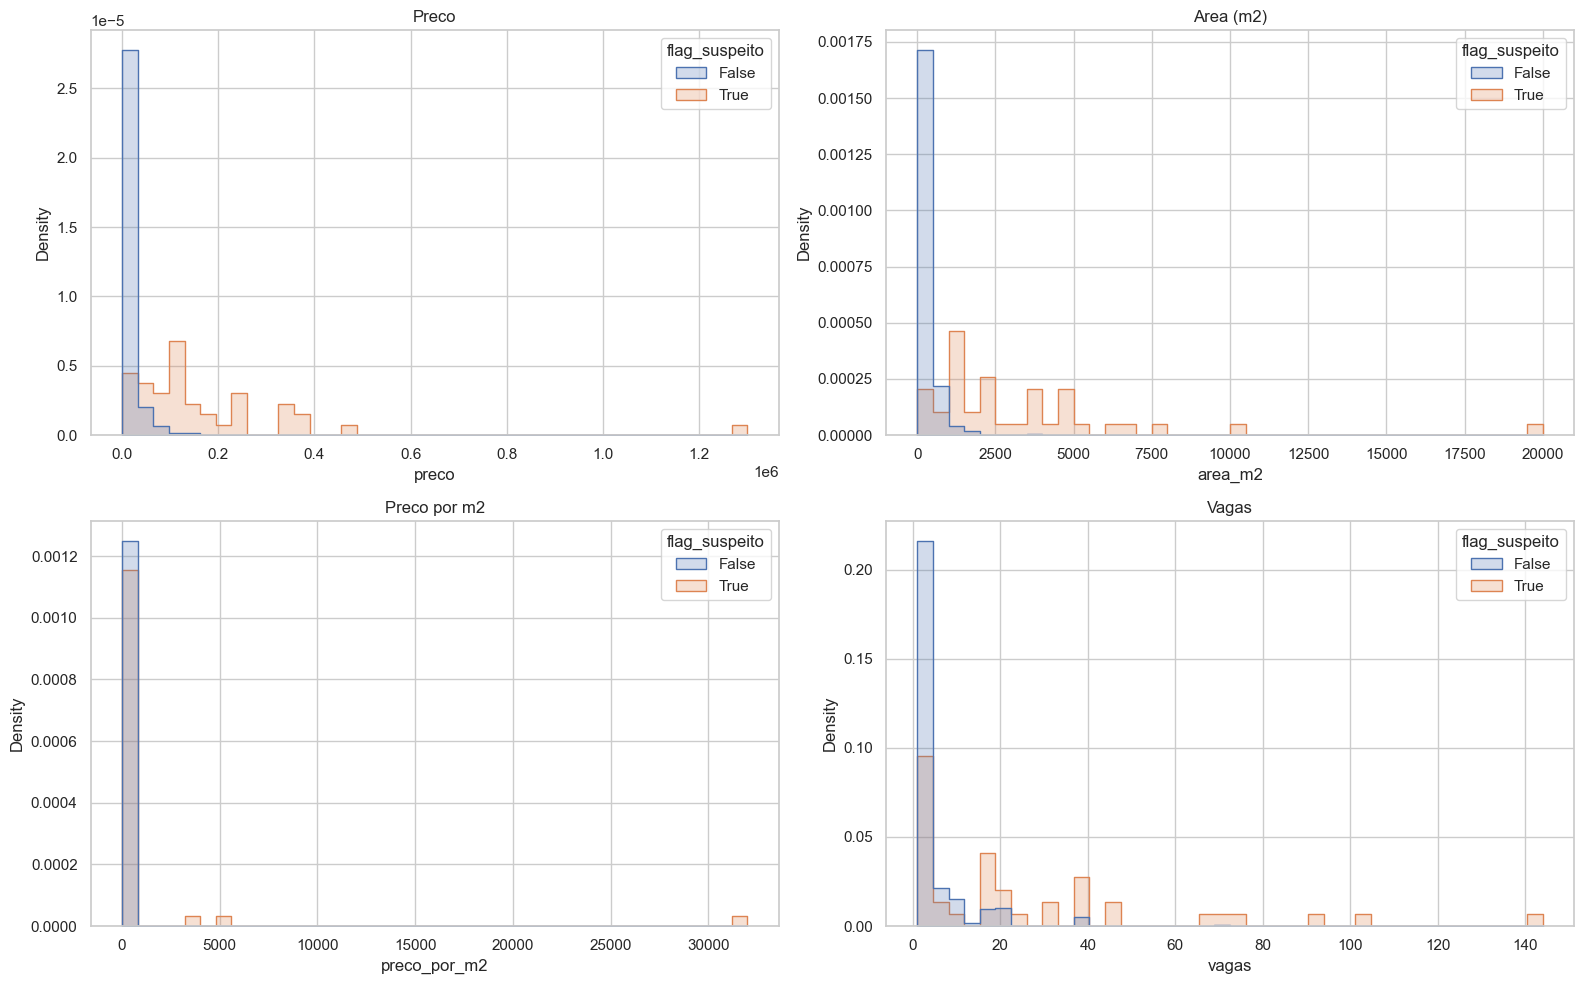

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for axis, column, title in zip(axes.flat, ['preco', 'area_m2', 'preco_por_m2', 'vagas'], ['Preco', 'Area (m2)', 'Preco por m2', 'Vagas']):
    sns.histplot(data=silver, x=column, hue='flag_suspeito', bins=40, ax=axis, element='step', stat='density', common_norm=False)
    axis.set_title(title)
plt.tight_layout()

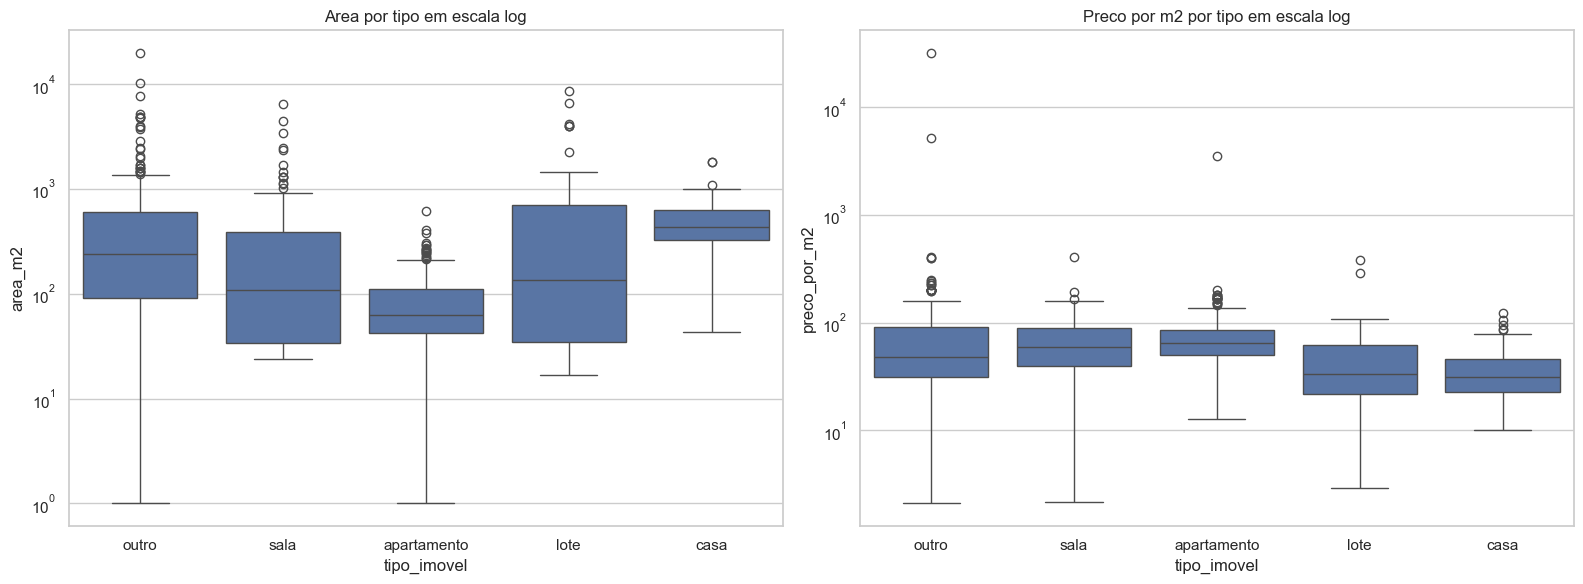

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=silver, x='tipo_imovel', y='area_m2', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Area por tipo em escala log')
sns.boxplot(data=silver, x='tipo_imovel', y='preco_por_m2', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Preco por m2 por tipo em escala log')
plt.tight_layout()

## 6. Estatísticas Gold e target

As estatísticas são calculadas somente no treino limpo e aplicadas aos demais splits. A distribuição do target deve ser interpretada levando em conta esse contrato.

In [ ]:
stats.head(20)

,id_bairro,bairro,tipo_imovel,preco_mediano_por_m2,preco_mad,area_mediana_m2,area_mad
0,3,Asa Norte,apartamento,70.200,17.420,79.0,39.5
1,3,Asa Norte,casa,54.030,1.530,161.0,1.0
2,3,Asa Norte,lote,46.880,24.660,54.0,22.0
3,3,Asa Norte,outro,46.670,11.840,314.0,186.0
4,3,Asa Norte,sala,68.900,19.805,65.5,39.0
5,7,Asa Sul,apartamento,65.735,14.000,120.5,49.5
6,7,Asa Sul,lote,32.380,5.100,41.5,14.5
7,7,Asa Sul,outro,159.520,40.790,134.0,64.0
8,7,Asa Sul,sala,85.715,35.810,128.5,98.5
9,17,Ceilândia,apartamento,29.030,8.760,44.0,18.0


In [ ]:
target_labels = {0: 'Barato', 1: 'Preco Justo', 2: 'Caro'}
target_by_split = []
for name, frame in splits.items():
    counts = frame['target_preco'].value_counts().rename(index=target_labels)
    for label, count in counts.items():
        target_by_split.append({'split': name, 'classe': label, 'quantidade': count, 'percentual': count / len(frame) * 100})
pd.DataFrame(target_by_split)

,split,classe,quantidade,percentual
0,train,Preco Justo,345,54.761905
1,train,Caro,157,24.920635
2,train,Barato,128,20.317460
3,valid,Preco Justo,50,37.037037
4,valid,Barato,43,31.851852
5,valid,Caro,42,31.111111
6,test,Preco Justo,57,42.222222
7,test,Caro,40,29.629630
8,test,Barato,38,28.148148


In [ ]:
pd.crosstab(gold['tipo_imovel'], gold['target_preco']).rename(columns=target_labels)

target_preco,Barato,Preco Justo,Caro
tipo_imovel,,,
apartamento,70,184,112
casa,24,60,26
lote,14,24,15
outro,55,107,54
sala,46,77,32


## 7. Splits temporais e perguntas para a próxima investigação

Perguntas sugeridas:

- Por que o volume bruto observado nesta execução foi 900 e não o volume esperado?
- Quais motivos de suspeita se concentram em cada tipo de imóvel?
- `outro` ainda representa muitos anúncios que poderiam ser classificados por regras adicionais?
- Há bairros e tipos com poucos registros para sustentar medianas e MADs?
- A distribuição de `target_preco` é estável entre treino, validação e teste?
- Quais suspeitos devem ser revisados manualmente ou enviados ao futuro agente LLM?

In [ ]:
split_summary = []
for name, frame in splits.items():
    split_summary.append({
        'split': name,
        'registros': len(frame),
        'suspeitos': int(frame['flag_suspeito'].fillna(False).sum()),
        'primeira_data': frame['data_extracao'].min(),
        'ultima_data': frame['data_extracao'].max(),
    })
pd.DataFrame(split_summary)

,split,registros,suspeitos,primeira_data,ultima_data
0,train,630,32,1.789851e+12,1.789851e+12
1,valid,135,5,1.789851e+12,1.789851e+12
2,test,135,4,1.789851e+12,1.789851e+12
